# 2023-24 Win Probability Modeling (Baseline)

This notebook builds a **75/25 random train/test split** from:
`/Users/robschoen/Dropbox/CC/GLA/data/pbp/processed/winprob_base/regular/stacked_2023-24_winprob_base.csv`

Model setup requested:
- Target: sign of `final_score_diff` (`1` = home win, `-1` = home loss)
- Predictors:
  - `game_seconds_left = full_q_left * 720 + seconds_left`
  - `current_differential` (from `differential`)
  - `possession_numeric` (`1` home, `0` undetermined, `-1` road)

For OT periods, `full_q_left = 0`.

Evaluation focus:
- **Primary metric:** Brier Score for home-win probability (lower is better)
- Reliability check: calibration plot

In [1]:
# Optional (run once if needed)
# %pip install scikit-learn matplotlib

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    RandomForestClassifier,
    VotingClassifier,
)
from sklearn.frozen import FrozenEstimator
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    f1_score,
    log_loss,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
import sklearn

RANDOM_STATE = 42
TEST_SIZE = 0.25
DATA_PATH = Path('/Users/robschoen/Dropbox/CC/GLA/data/pbp/processed/winprob_base/regular/stacked_2023-24_winprob_base.csv')

print('scikit-learn version:', sklearn.__version__)
print('Data path exists:', DATA_PATH.exists())

scikit-learn version: 1.7.2
Data path exists: True


In [2]:
# Load and validate required columns
required_cols = [
    'home',
    'road',
    'quarter',
    'seconds_left',
    'differential',
    'possession',
    'final_score_diff',
]

df = pd.read_csv(DATA_PATH)
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f'Missing required columns: {missing}')

print('rows:', len(df), 'columns:', len(df.columns))
display(df[required_cols].head())

rows: 598705 columns: 10


,home,road,quarter,seconds_left,differential,possession,final_score_diff
0,DEN,LAL,1,720,0,NaN,12
1,DEN,LAL,1,720,0,NaN,12
2,DEN,LAL,1,702,-2,DEN,12
3,DEN,LAL,1,675,0,LAL,12
4,DEN,LAL,1,657,-3,DEN,12


In [3]:
# Feature engineering + target
model_df = df[required_cols].copy()

# Target sign: +1 home win, -1 home loss
model_df['target_home_win_sign'] = np.where(model_df['final_score_diff'] > 0, 1, -1)

# full_q_left: 4-quarter for regulation, 0 for OT
model_df['full_q_left'] = np.where(model_df['quarter'] <= 4, 4 - model_df['quarter'], 0)
model_df['game_seconds_left'] = model_df['full_q_left'] * 720 + model_df['seconds_left']

# Current differential (already in the source data)
model_df['current_differential'] = model_df['differential']

# possession -> numeric: home=1, road=-1, undetermined=0
model_df['possession_numeric'] = np.select(
    [
        model_df['possession'] == model_df['home'],
        model_df['possession'] == model_df['road'],
    ],
    [1, -1],
    default=0,
).astype(int)

feature_cols = ['game_seconds_left', 'current_differential', 'possession_numeric']
X = model_df[feature_cols]
y = model_df['target_home_win_sign']

print('Target distribution:')
print(y.value_counts(normalize=True).rename('share').sort_index())
print('Feature preview:')
display(X.head())

Target distribution:
target_home_win_sign
-1    0.454556
 1    0.545444
Name: share, dtype: float64
Feature preview:


,game_seconds_left,current_differential,possession_numeric
0,2880,0,0
1,2880,0,0
2,2862,-2,1
3,2835,0,-1
4,2817,-3,1


In [4]:
# 75/25 random split (stratified by target sign)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Train target share:')
print(y_train.value_counts(normalize=True).rename('share').sort_index())
print('Test target share:')
print(y_test.value_counts(normalize=True).rename('share').sort_index())

Train shape: (449028, 3)
Test shape: (149677, 3)
Train target share:
target_home_win_sign
-1    0.454555
 1    0.545445
Name: share, dtype: float64
Test target share:
target_home_win_sign
-1    0.454559
 1    0.545441
Name: share, dtype: float64


In [5]:
# Baseline models to compare (ranked by Brier Score)
logistic_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
)
rf_model = RandomForestClassifier(
    n_estimators=250,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
gb_model = HistGradientBoostingClassifier(
    max_depth=6,
    random_state=RANDOM_STATE,
)

models = {
    'DummyMostFrequent': DummyClassifier(strategy='most_frequent'),
    'LogisticRegression': logistic_model,
    'RandomForest': rf_model,
    'HistGradientBoosting': gb_model,
    'EnsembleSoftVote': VotingClassifier(
        estimators=[
            ('lr', logistic_model),
            ('rf', rf_model),
            ('gb', gb_model),
        ],
        voting='soft',
    ),
}

fitted_models = {}
home_win_probs = {}
rows = []
y_test_bin = (y_test == 1).astype(int)

for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model

    y_pred = model.predict(X_test)

    classes = model.classes_
    home_idx = np.where(classes == 1)[0][0]
    p_home = model.predict_proba(X_test)[:, home_idx]
    home_win_probs[name] = p_home

    rows.append(
        {
            'model': name,
            'brier_home_win': brier_score_loss(y_test_bin, p_home),
            'log_loss_home_win': log_loss(y_test_bin, p_home, labels=[0, 1]),
            'roc_auc_home_win': roc_auc_score(y_test_bin, p_home),
            'accuracy': accuracy_score(y_test, y_pred),
            'f1_home_win': f1_score(y_test, y_pred, pos_label=1),
        }
    )

results = pd.DataFrame(rows).sort_values('brier_home_win').reset_index(drop=True)
display(results)

/opt/miniconda3/envs/nba2026/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/envs/nba2026/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/envs/nba2026/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/envs/nba2026/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/nba2026/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/nba2026/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid val

,model,brier_home_win,log_loss_home_win,roc_auc_home_win,accuracy,f1_home_win
0,EnsembleSoftVote,0.156109,0.465145,0.851243,0.759222,0.786589
1,RandomForest,0.160451,0.484124,0.846639,0.754926,0.778696
2,HistGradientBoosting,0.160539,0.473649,0.841816,0.751739,0.782420
3,LogisticRegression,0.167176,0.499309,0.830121,0.751258,0.777402
4,DummyMostFrequent,0.454559,16.383960,0.500000,0.545441,0.705871


In [6]:
# Quick look at the best model's class predictions (by Brier Score)
best_model_name = results.iloc[0]['model']
best_model = fitted_models[best_model_name]
best_pred = best_model.predict(X_test)

print('Best model by Brier Score:', best_model_name)
print(pd.crosstab(y_test, best_pred, rownames=['actual'], colnames=['predicted']))

/opt/miniconda3/envs/nba2026/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/nba2026/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/nba2026/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Best model by Brier Score: EnsembleSoftVote
predicted     -1      1
actual                 
-1         47222  20815
 1         15224  66416


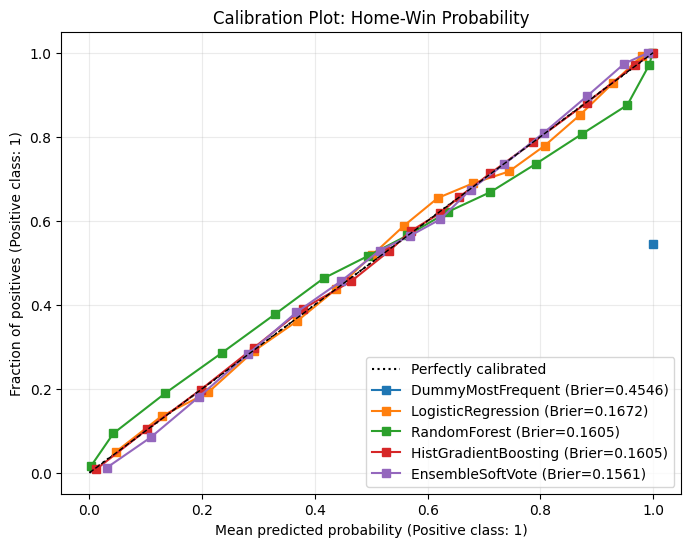

In [7]:
# Calibration plot: predicted home-win probability vs observed frequency
fig, ax = plt.subplots(figsize=(8, 6))

for name, p_home in home_win_probs.items():
    brier = results.loc[results['model'] == name, 'brier_home_win'].iloc[0]
    CalibrationDisplay.from_predictions(
        y_test_bin,
        p_home,
        n_bins=15,
        strategy='quantile',
        name=f"{name} (Brier={brier:.4f})",
        ax=ax,
    )

ax.plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1)
ax.set_title('Calibration Plot: Home-Win Probability')
ax.grid(alpha=0.25)
plt.show()

## Additional Experiments

The next three cells implement:
1. Interaction terms for linear models.
2. Phase-sliced test evaluation (early, late, clutch).
3. Isotonic vs sigmoid calibration using Brier deltas.

### 1) Interaction Terms For Logistic Regression

Adds pairwise interactions (including `game_seconds_left * current_differential`) and compares test metrics against the base logistic model.

In [8]:
# Compare base logistic vs logistic with interaction terms
logit_base = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
)

logit_interactions = make_pipeline(
    PolynomialFeatures(degree=2, interaction_only=True, include_bias=False),
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
)

linear_models = {
    'Logistic_Base': logit_base,
    'Logistic_Interactions': logit_interactions,
}

y_test_bin = (y_test == 1).astype(int)
interaction_rows = []

for name, model in linear_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    home_idx = np.where(model.classes_ == 1)[0][0]
    p_home = model.predict_proba(X_test)[:, home_idx]

    interaction_rows.append(
        {
            'model': name,
            'brier_home_win': brier_score_loss(y_test_bin, p_home),
            'log_loss_home_win': log_loss(y_test_bin, p_home, labels=[0, 1]),
            'roc_auc_home_win': roc_auc_score(y_test_bin, p_home),
            'accuracy': accuracy_score(y_test, y_pred),
        }
    )

interaction_results = pd.DataFrame(interaction_rows).sort_values('brier_home_win').reset_index(drop=True)
display(interaction_results)

/opt/miniconda3/envs/nba2026/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/envs/nba2026/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/envs/nba2026/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/envs/nba2026/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/nba2026/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/nba2026/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid val

,model,brier_home_win,log_loss_home_win,roc_auc_home_win,accuracy
0,Logistic_Interactions,0.162522,0.482365,0.838900,0.751692
1,Logistic_Base,0.167176,0.499309,0.830121,0.751258


### 2) Test Performance By Game Phase

Phase definition:
- `early`: more than 12:00 left in game (`game_seconds_left > 720`)
- `clutch`: 5:00 or less with margin 5 or less
- `late`: everything else

In [9]:
# Evaluate each trained model by game phase on test data
phase_eval = X_test.copy()
phase_eval['y_true_bin'] = (y_test == 1).astype(int)

phase_eval['phase'] = np.where(
    phase_eval['game_seconds_left'] > 720,
    'early',
    np.where(
        (phase_eval['game_seconds_left'] <= 300) & (phase_eval['current_differential'].abs() <= 5),
        'clutch',
        'late',
    ),
)

phase_rows = []
for model_name, p_home in home_win_probs.items():
    tmp = phase_eval.copy()
    tmp['p_home'] = p_home

    for phase_name, g in tmp.groupby('phase', sort=False):
        y_phase = g['y_true_bin'].to_numpy()
        p_phase = g['p_home'].to_numpy()
        pred_phase = np.where(p_phase >= 0.5, 1, 0)

        phase_rows.append(
            {
                'model': model_name,
                'phase': phase_name,
                'n_rows': len(g),
                'brier_home_win': brier_score_loss(y_phase, p_phase),
                'roc_auc_home_win': roc_auc_score(y_phase, p_phase),
                'accuracy': accuracy_score(y_phase, pred_phase),
            }
        )

phase_results = (
    pd.DataFrame(phase_rows)
    .sort_values(['phase', 'brier_home_win'])
    .reset_index(drop=True)
)

display(phase_results)

,model,phase,n_rows,brier_home_win,roc_auc_home_win,accuracy
0,EnsembleSoftVote,clutch,6053,0.154868,0.864442,0.775483
1,HistGradientBoosting,clutch,6053,0.155236,0.855019,0.770197
2,RandomForest,clutch,6053,0.155837,0.856785,0.767884
3,LogisticRegression,clutch,6053,0.197034,0.831296,0.768379
4,DummyMostFrequent,clutch,6053,0.475797,0.500000,0.524203
5,EnsembleSoftVote,early,109811,0.183703,0.792185,0.712196
6,HistGradientBoosting,early,109811,0.189186,0.778434,0.703272
7,RandomForest,early,109811,0.189501,0.785743,0.706851
8,LogisticRegression,early,109811,0.192980,0.773969,0.702671
9,DummyMostFrequent,early,109811,0.455665,0.500000,0.544335


### 3) Calibrate Best Uncalibrated Single Model

Chooses the best **single** model by test Brier Score (excluding dummy and ensemble), then compares:
- uncalibrated
- sigmoid calibration
- isotonic calibration

Calibration fit uses a holdout slice from `X_train`/`y_train` only.

Best uncalibrated single model: RandomForest


/opt/miniconda3/envs/nba2026/lib/python3.10/site-packages/sklearn/calibration.py:867: RuntimeWarning: divide by zero encountered in matmul
  grad = np.asarray([-g @ F, -g.sum()], dtype=np.float64)
/opt/miniconda3/envs/nba2026/lib/python3.10/site-packages/sklearn/calibration.py:867: RuntimeWarning: overflow encountered in matmul
  grad = np.asarray([-g @ F, -g.sum()], dtype=np.float64)
/opt/miniconda3/envs/nba2026/lib/python3.10/site-packages/sklearn/calibration.py:867: RuntimeWarning: invalid value encountered in matmul
  grad = np.asarray([-g @ F, -g.sum()], dtype=np.float64)


,variant,brier_home_win,log_loss_home_win,brier_delta_vs_uncalibrated
0,RandomForest_isotonic,0.160383,0.475832,-0.002127
1,RandomForest_uncalibrated,0.162510,0.486073,0.000000
2,RandomForest_sigmoid,0.163305,0.492000,0.000795


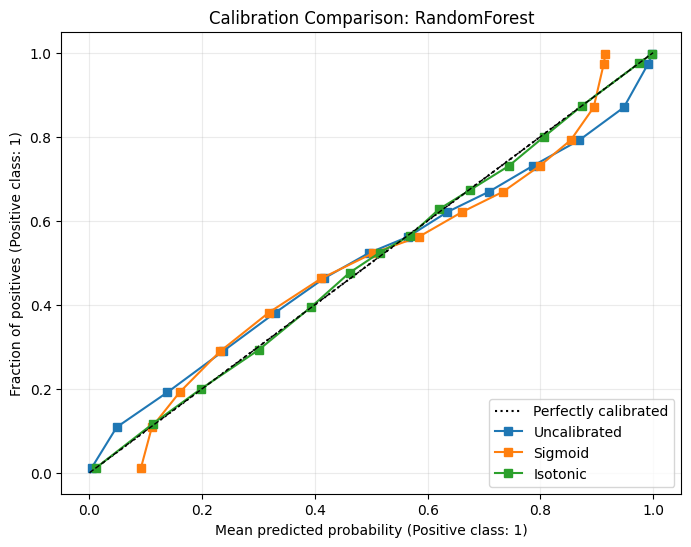

In [10]:
# Calibrate the best uncalibrated single model and compare Brier deltas
single_model_names = ['LogisticRegression', 'RandomForest', 'HistGradientBoosting']
best_single_name = (
    results[results['model'].isin(single_model_names)]
    .sort_values('brier_home_win')
    .iloc[0]['model']
)
print('Best uncalibrated single model:', best_single_name)

X_fit, X_cal, y_fit, y_cal = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train,
)

y_test_bin = (y_test == 1).astype(int)

base_model = clone(models[best_single_name])
base_model.fit(X_fit, y_fit)
base_idx = np.where(base_model.classes_ == 1)[0][0]
p_base = base_model.predict_proba(X_test)[:, base_idx]

cal_sigmoid = CalibratedClassifierCV(
    estimator=FrozenEstimator(base_model),
    method='sigmoid',
)
cal_sigmoid.fit(X_cal, y_cal)
p_sigmoid = cal_sigmoid.predict_proba(X_test)[:, 1]

cal_isotonic = CalibratedClassifierCV(
    estimator=FrozenEstimator(base_model),
    method='isotonic',
)
cal_isotonic.fit(X_cal, y_cal)
p_isotonic = cal_isotonic.predict_proba(X_test)[:, 1]

calibration_compare = pd.DataFrame(
    [
        {
            'variant': f'{best_single_name}_uncalibrated',
            'brier_home_win': brier_score_loss(y_test_bin, p_base),
            'log_loss_home_win': log_loss(y_test_bin, p_base, labels=[0, 1]),
        },
        {
            'variant': f'{best_single_name}_sigmoid',
            'brier_home_win': brier_score_loss(y_test_bin, p_sigmoid),
            'log_loss_home_win': log_loss(y_test_bin, p_sigmoid, labels=[0, 1]),
        },
        {
            'variant': f'{best_single_name}_isotonic',
            'brier_home_win': brier_score_loss(y_test_bin, p_isotonic),
            'log_loss_home_win': log_loss(y_test_bin, p_isotonic, labels=[0, 1]),
        },
    ]
).sort_values('brier_home_win').reset_index(drop=True)

base_brier = calibration_compare.loc[
    calibration_compare['variant'] == f'{best_single_name}_uncalibrated',
    'brier_home_win',
].iloc[0]
calibration_compare['brier_delta_vs_uncalibrated'] = calibration_compare['brier_home_win'] - base_brier

display(calibration_compare)

fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(y_test_bin, p_base, n_bins=15, strategy='quantile', name='Uncalibrated', ax=ax)
CalibrationDisplay.from_predictions(y_test_bin, p_sigmoid, n_bins=15, strategy='quantile', name='Sigmoid', ax=ax)
CalibrationDisplay.from_predictions(y_test_bin, p_isotonic, n_bins=15, strategy='quantile', name='Isotonic', ax=ax)
ax.plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1)
ax.set_title(f'Calibration Comparison: {best_single_name}')
ax.grid(alpha=0.25)
plt.show()